In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob

In [ ]:
case_name = 'CUPiD_test_ensemble'
component = 'ice'
CESM_output_dir = '/glade/u/home/mollyw/scratch/archive/'
ts_dir = CESM_output_dir + f'{case_name}/{component}/proc/tseries/'
inst = 3

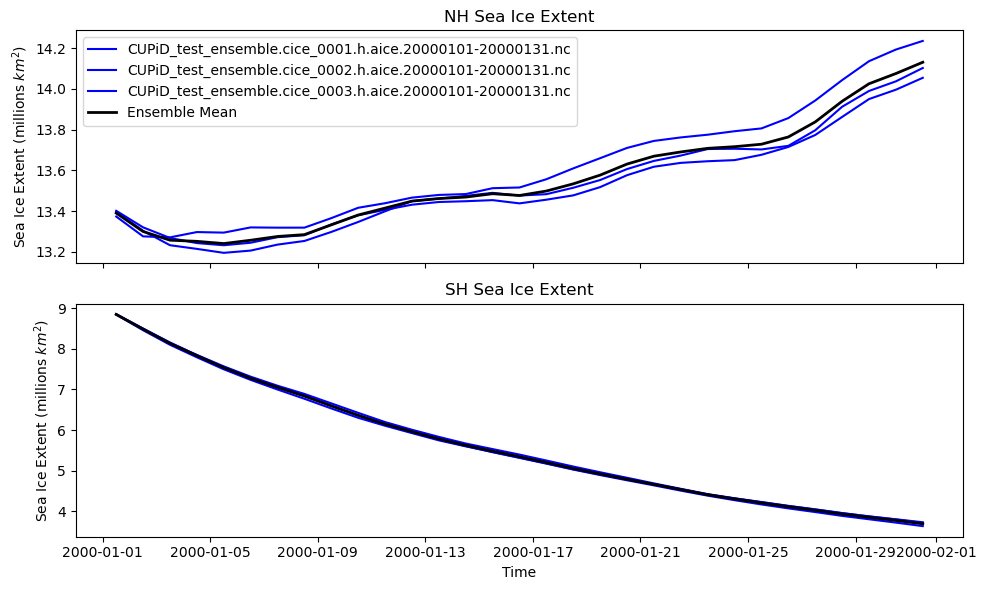

In [36]:
fig, axes = plt.subplots(2,1, figsize=(10, 6))

files = sorted(glob.glob(ts_dir + case_name + '.cice_*.aice.*.nc'))
member_nh_sie = []
member_sh_sie = []
for f in files:
    ds = xr.open_dataset(f)
    tarea = xr.open_dataset('/glade/campaign/cesm/community/omwg/za_grids/gx1v6_grid_info.nc')['TAREA']
    sic_area = ds['aice']*tarea.values * 1e-10 * 1e-6
    nh_sie = sic_area.where(ds['aice'] > 0.15).where(ds['TLAT'] > 50).sum(dim=['ni', 'nj'])
    sh_sie = sic_area.where(ds['aice'] > 0.15).where(ds['TLAT'] < -50).sum(dim=['ni', 'nj'])
    time = ds.time.astype('datetime64[ns]')
    axes[0].plot(time, nh_sie, label=f.split('/')[-1], color = 'blue')
    axes[1].plot(time, sh_sie, label=f.split('/')[-1], color = 'blue')

    member_nh_sie.append(nh_sie)
    member_sh_sie.append(sh_sie)    
    ds.close()

member_nh_sie = xr.concat(member_nh_sie, dim='member')
member_sh_sie = xr.concat(member_sh_sie, dim='member')

axes[0].plot(time, member_nh_sie.mean(dim='member'), label='Ensemble Mean', color='black', linewidth=2)
axes[1].plot(time, member_sh_sie.mean(dim='member'), label='Ensemble Mean', color='black', linewidth=2)

axes[0].set_title('NH Sea Ice Extent')
axes[1].set_title('SH Sea Ice Extent')
axes[0].set_xticklabels([])  # Hide x-axis labels for the top plot]
axes[1].set_xlabel('Time')
axes[0].set_ylabel('Sea Ice Extent (millions $km^2$)')
axes[1].set_ylabel('Sea Ice Extent (millions $km^2$)')

axes[0].legend()
plt.tight_layout()